In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\Soumya Bhardwaj\ML_PROJECT1\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
import mne
import os

print("MNE version:", mne.__version__)

MNE version: 1.12.1


In [4]:
from pathlib import Path
import mne

edf_path = Path("data/CHB-MIT/chb01/chb01_03.edf")

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

print(raw)

FileNotFoundError: File does not exist: "c:\Users\Soumya Bhardwaj\data\CHB-MIT\chb01\chb01_03.edf"

In [5]:
from pathlib import Path
import mne

edf_path = Path("data/CHB-MIT/chb01/chb01_03.edf")

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

print(raw)

FileNotFoundError: File does not exist: "c:\Users\Soumya Bhardwaj\data\CHB-MIT\chb01\chb01_03.edf"

In [6]:
edf_path = Path("data/CHB-MIT/chb01/chb01_03.edf")

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

print(raw)

FileNotFoundError: File does not exist: "c:\Users\Soumya Bhardwaj\data\CHB-MIT\chb01\chb01_03.edf"

In [7]:
from pathlib import Path
import sys
import mne

# Find the project root from the Python environment we're currently using
project_root = Path(sys.executable).resolve().parents[2]

edf_path = project_root / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", project_root)
print("EDF path:", edf_path)
print("File exists:", edf_path.exists())

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

print(raw)

Project root: C:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF path: C:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
File exists: True
<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~22 KiB, data not loaded>


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_13860\1416546414.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


In [8]:
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Number of channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")
print("\nChannel names:")
for i, ch in enumerate(raw.ch_names, start=1):
    print(f"{i:2d}. {ch}")

Sampling frequency: 256.0 Hz
Number of channels: 23
Duration: 3599.99609375 seconds

Channel names:
 1. FP1-F7
 2. F7-T7
 3. T7-P7
 4. P7-O1
 5. FP1-F3
 6. F3-C3
 7. C3-P3
 8. P3-O1
 9. FP2-F4
10. F4-C4
11. C4-P4
12. P4-O2
13. FP2-F8
14. F8-T8
15. T8-P8-0
16. P8-O2
17. FZ-CZ
18. CZ-PZ
19. P7-T7
20. T7-FT9
21. FT9-FT10
22. FT10-T8
23. T8-P8-1


In [9]:
from pathlib import Path

seizure_path = project_root / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf.seizures"

print("Annotation file:", seizure_path)
print("File exists:", seizure_path.exists())

Annotation file: C:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf.seizures
File exists: True


In [10]:
import numpy as np

with open(seizure_path, "rb") as f:
    seizure_bytes = f.read()

print("Annotation file size:", len(seizure_bytes), "bytes")
print("Raw bytes:", seizure_bytes)

Annotation file size: 54 bytes
Raw bytes: b'\x00X\x17\xfc## time resolution: 256\x00\x00\xec\xff\xff\xff\xff\x01\x00\x00\xec\x0b\x00\x00\xb4\x00\x80\x00\xec\x00\x00\x00(\x00\x84\x00\x00'


In [11]:
# Seizure annotation from the CHB-MIT recording metadata
seizure_start = 2996
seizure_end = 3036

print(f"Seizure start: {seizure_start} s")
print(f"Seizure end:   {seizure_end} s")
print(f"Seizure duration: {seizure_end - seizure_start} s")

Seizure start: 2996 s
Seizure end:   3036 s
Seizure duration: 40 s


In [12]:
# Load 10 seconds before and after the seizure
plot_start = seizure_start - 10
plot_end = seizure_end + 10

seizure_raw = raw.copy().crop(
    tmin=plot_start,
    tmax=plot_end
)

print(seizure_raw)

<RawEDF | chb01_03.edf, 23 x 15361 (60.0 s), ~22 KiB, data not loaded>


Using matplotlib as 2D backend.


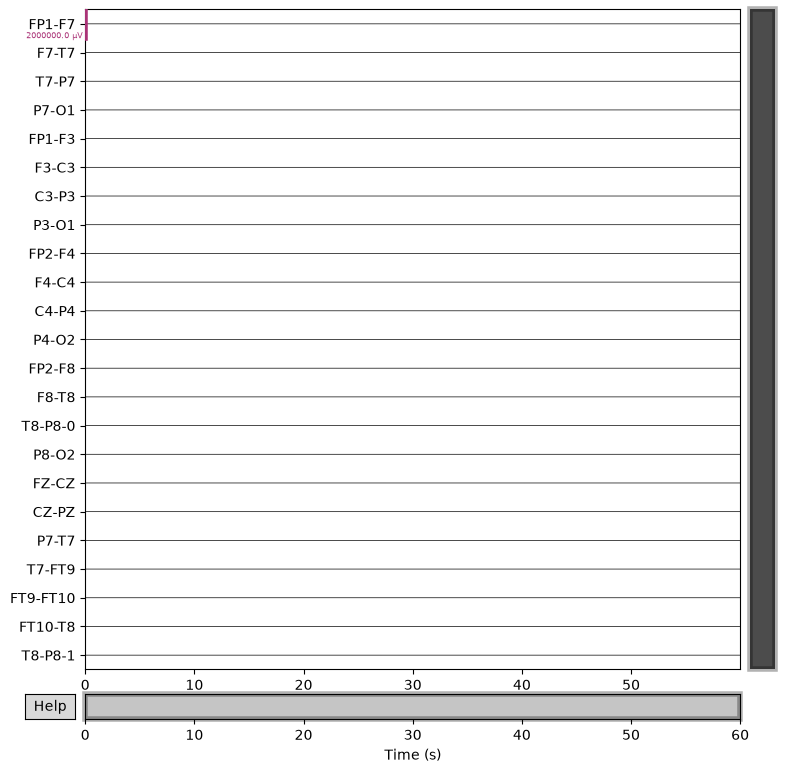

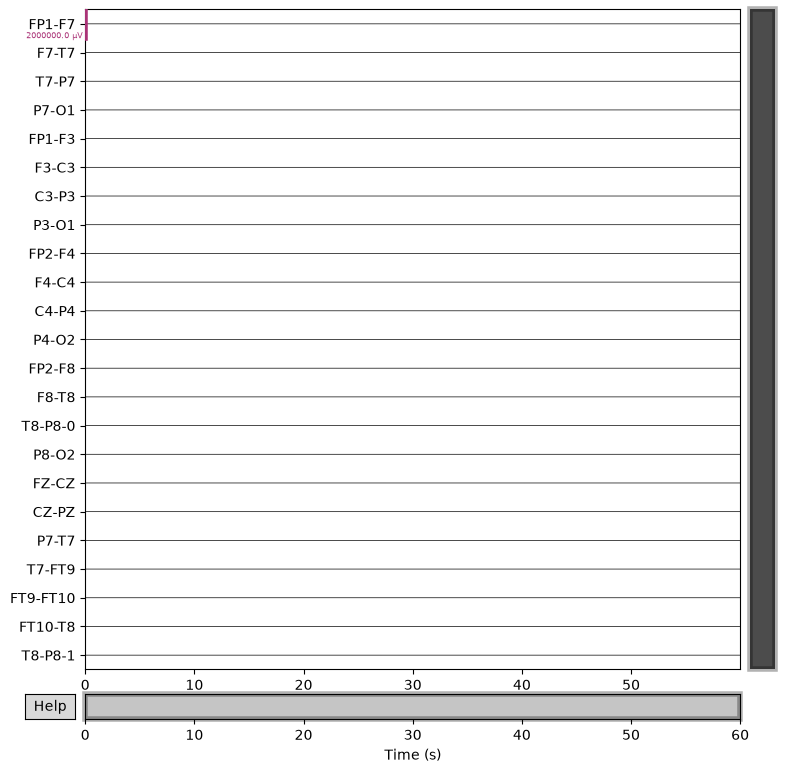

In [13]:
seizure_raw.plot(
    duration=60,
    n_channels=23,
    scalings="auto",
    title="CHB-MIT chb01_03 — Seizure at 2996–3036 s"
)

In [14]:
# Load the actual signal values from the 60-second segment
data = seizure_raw.get_data()

print("Data shape:", data.shape)
print("Minimum:", data.min())
print("Maximum:", data.max())
print("Standard deviation:", data.std())

Data shape: (23, 15361)
Minimum: -0.0005933089133089134
Maximum: 0.0005565811965811965
Standard deviation: 8.517061994811858e-05


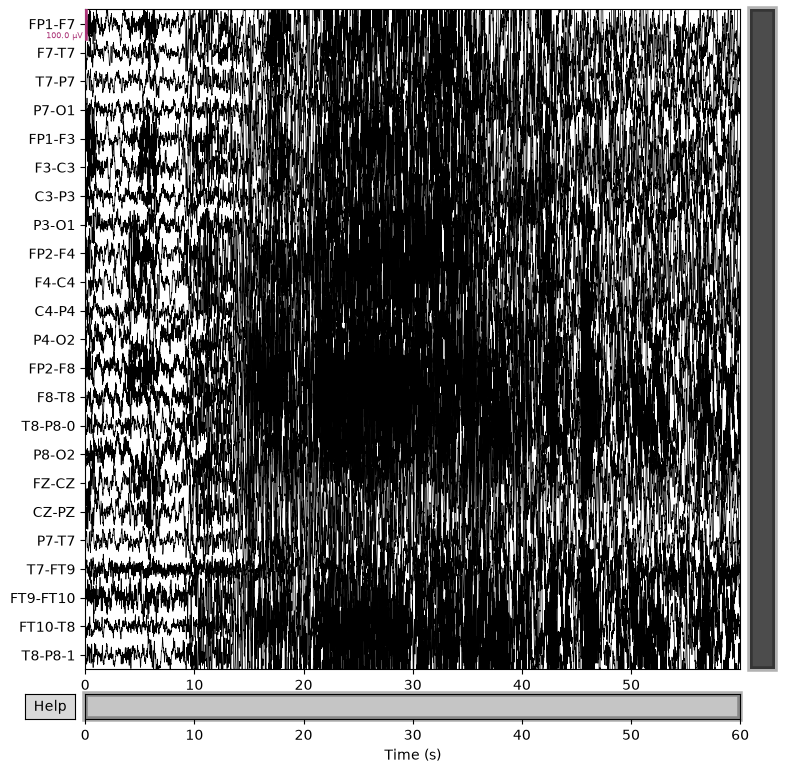

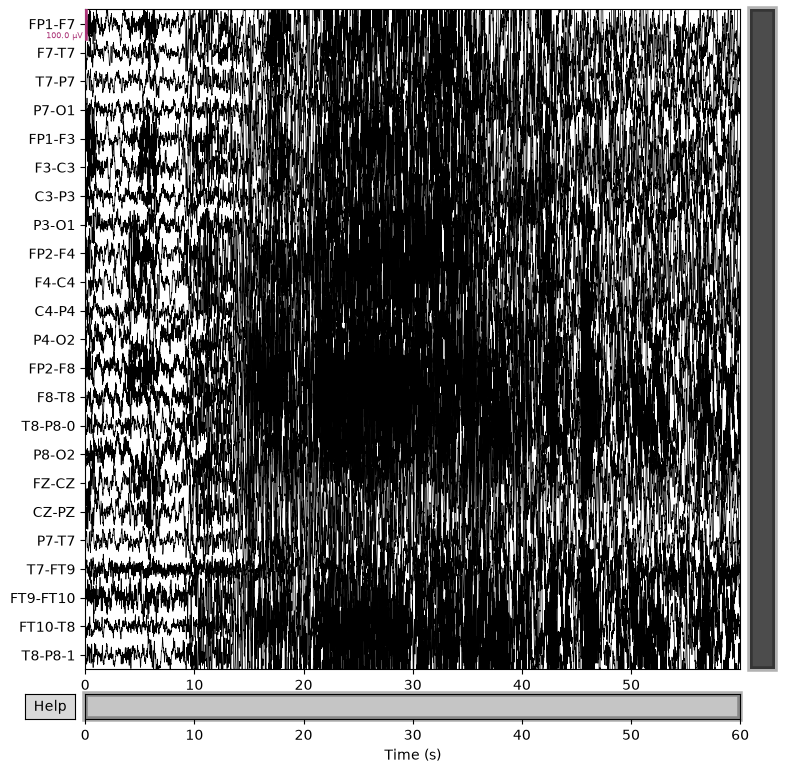

In [15]:
seizure_raw.plot(
    duration=60,
    n_channels=23,
    scalings=dict(eeg=50e-6),
    title="CHB-MIT chb01_03 — 10 s before to 10 s after seizure"
)

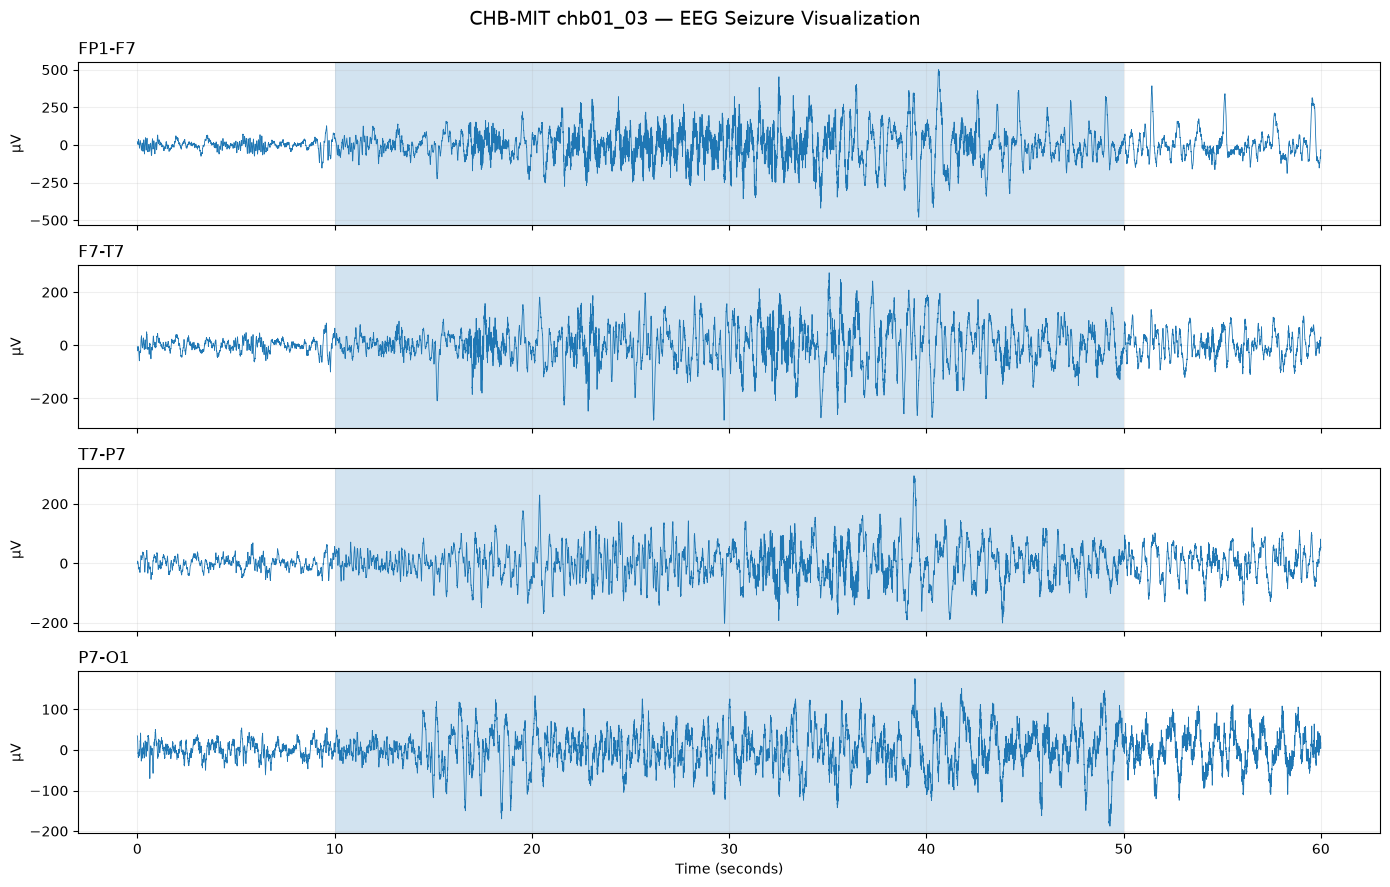

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Select 4 representative EEG channels
channels_to_plot = [
    "FP1-F7",
    "F7-T7",
    "T7-P7",
    "P7-O1"
]

# Extract only these channels
clean_raw = seizure_raw.copy().pick(channels_to_plot)

# Get signal data
signals = clean_raw.get_data()
times = clean_raw.times

# Convert from Volts → microvolts
signals_uv = signals * 1e6

# Create figure
fig, axes = plt.subplots(
    len(channels_to_plot),
    1,
    figsize=(14, 9),
    sharex=True
)

# Plot each channel
for i, ax in enumerate(axes):
    ax.plot(times, signals_uv[i], linewidth=0.6)
    ax.set_ylabel("µV")
    ax.set_title(channels_to_plot[i], loc="left")
    ax.grid(alpha=0.2)

# Mark seizure region
for ax in axes:
    ax.axvspan(
        seizure_start - plot_start,
        seizure_end - plot_start,
        alpha=0.2
    )

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    "CHB-MIT chb01_03 — EEG Seizure Visualization",
    fontsize=14
)

plt.tight_layout()
plt.show()